### MNIST Classification  

In [3]:
pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
    --------------------------------------- 8.1/351.2 MB 40.8 MB/s eta 0:00:09
   -- ------------------------------------- 19.1/351.2 MB 45.8 MB/s eta 0:00:08
   --- ------------------------------------ 27.3/351.2 MB 43.3 MB/s eta 0:00:08
   ---- ----------------------------------- 37.0/351.2 MB 43.4 MB/s eta 0:00:08
   ----- ---------------------------------- 46.9/351.2 MB 44.0 MB/s eta 0:00:07
   ------ --------------------------------- 56.9/351.2 MB 44.6 MB/s eta 0:00:07
   ------- -------------------------------- 67.9/351.2 MB 45.4 MB/s eta 0:00:07
   --------- ------------------------------ 80.2/351.2 MB 47.0 MB/s eta 0:00:06
   ---------- ----------------------------- 92.8/351.2 MB 48.1 MB/s eta 0:00:06
   ----------- --------------------------- 104.6/351.2 MB 48.9 MB/s eta 0:00:06
   ------------- ------------------------- 118.2/351.2 MB 50.1 MB/s eta 0:00:05
   -------------- ------------------------ 131.1/3

In [4]:
import tensorflow

In [5]:
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten

In [7]:
(X_train,y_train),(X_test,y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [9]:
X_train.shape

(60000, 28, 28)

In [10]:
X_test.shape

(10000, 28, 28)

In [11]:
y_train.shape

(60000,)

In [12]:
import matplotlib.pyplot as plt

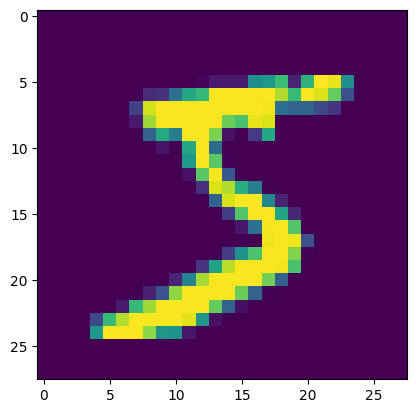

In [13]:
plt.imshow(X_train[0])

In [14]:
X_train = X_train/255
X_test = X_test/255

In [15]:
model = Sequential()

In [16]:
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))

C:\Users\dspri\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [22]:
history = model.fit(X_train,y_train,epochs=25,validation_split=0.2)

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9163 - loss: 0.2923 - val_accuracy: 0.9561 - val_loss: 0.1555
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9615 - loss: 0.1320 - val_accuracy: 0.9643 - val_loss: 0.1217
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9731 - loss: 0.0891 - val_accuracy: 0.9675 - val_loss: 0.1051
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9801 - loss: 0.0661 - val_accuracy: 0.9661 - val_loss: 0.1106
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9844 - loss: 0.0505 - val_accuracy: 0.9728 - val_loss: 0.0924
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9877 - loss: 0.0394 - val_accuracy: 0.9755 - val_loss: 0.0872
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9911 - loss: 0.0301 - val_accuracy: 0.9732 - val_loss: 0.0947
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9932 - loss: 0.0238 - 

In [23]:
y_prob = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [25]:
y_pred = y_prob.argmax(axis=1)

In [26]:
from sklearn.metrics import accuracy_score
score = accuracy_score(y_test,y_pred)

In [27]:
print(score)

0.9761


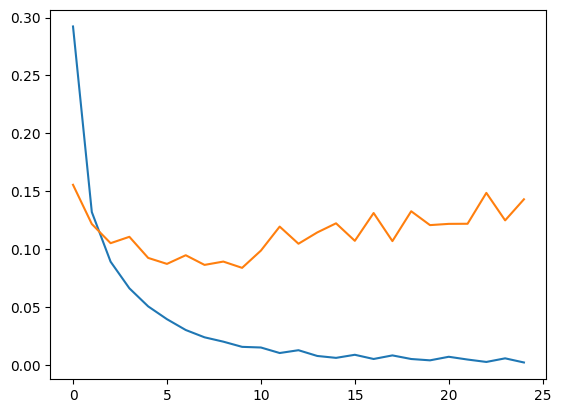

In [28]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [29]:
model.predict(X_test[1].reshape(1,28,28)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


array([2])

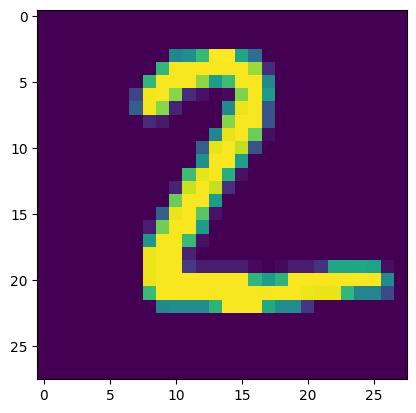

In [30]:
plt.imshow(X_test[1])